# 434 Lab 1 Report
**Name:** Austin Birkhofer  
**Lab Partner:** Kittipat Limpiyakorn

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# default plot size
plt.rcParams["figure.figsize"] = (9, 5)

## A Little Statistics

### 1. Sigma Stuff

#### 1.A About the Normal Distribution

The standard normal distribution has mean 0 and std dev 1:

$$f(z)=\frac{1}{\sqrt{2\pi}}e^{-z^2/2}.$$

The cdf of this is the area to the left of $z$, so we have

$$\Phi(z)=P(Z\leq z)=\int_{-\infty}^{z}f(t)\,dt.$$

#### 1.B Integrate at Sigma Values

`cdf(z)` gives the integral directly

In [14]:
print("sigma    CDF           upper tail")
for z in [1, 2, 3, 5]:
    cumulative = stats.norm.cdf(z)
    tail = stats.norm.sf(z) # equivalent to 1 - stats.norm.cdf(z)
    print(f"{z:5d}    {cumulative:.8f}    {tail:.8g}")

sigma    CDF           upper tail
    1    0.84134475    0.15865525
    2    0.97724987    0.022750132
    3    0.99865010    0.001349898
    5    0.99999971    2.8665157e-07


The cdf values at 1, 2, and 3 sigma match the z-tables in the wikipedia page. Upper tail is the area to the right.

#### 1.C Recovering Sigma

We use`ppf` on cumulative probs associated with the 1, 2, and 5 sigma.

In [19]:
print("original sigma    recovered sigma")
for z in [1, 2, 5]:
    probability = stats.norm.cdf(z)
    recovered = stats.norm.ppf(probability)
    print(f"{z:14d}    {recovered:.4f}")

original sigma    recovered sigma
             1    1.0000
             2    2.0000
             5    5.0000


#### 1.D Negative Result

In [22]:
print("Lower tail probability 0.158655:") # gathered from wiki page
print(stats.norm.ppf(0.158655))

Lower tail probability 0.158655:
-1.000001049431045


This gets us approximately -1 and the cutoff is one std dev below the mean. So, ppf take prob to the left, and thus for an upper tail prob we take pp(1-p) to get a positive sigma. So, negative sign describes cutoff position below mean.

### 2. Exponential Distribution

#### 2.A About the Exponential Distribution

I will choose the exponential dist with scale factor 2. The probability density function (using the wiki page) would then be

$$f(x)=\frac12e^{-x/2},\qquad x\geq0$$

with zero density for $x\leq0$. The mean and std dev are both 2.

#### 2.B Plots

We follow HW1 and use 100k samples to build our plots.

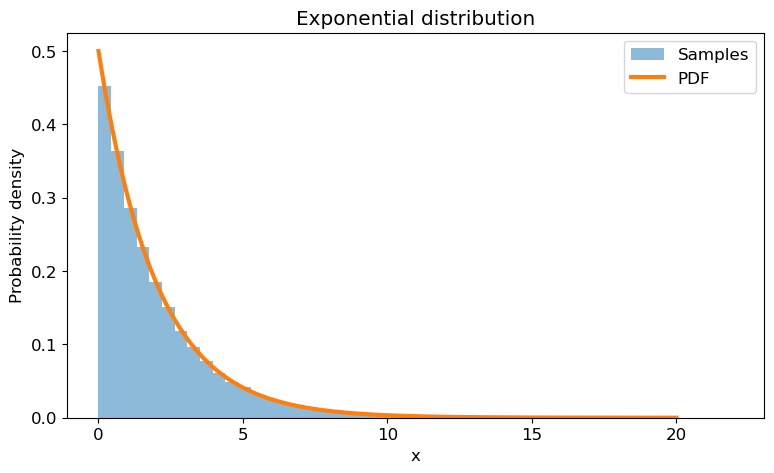

In [23]:
scale = 2.0
d = stats.expon.rvs(scale=scale, size=100000, random_state=434)
x = np.linspace(0, 20, 1000)

fig, ax = plt.subplots()
ax.hist(d, 50, density=True, alpha=0.5, label="Samples")
ax.plot(x, stats.expon.pdf(x, scale=scale), linewidth=3, label="PDF")
ax.set_xlabel("x")
ax.set_ylabel("Probability density")
ax.set_title("Exponential distribution")
ax.legend()
plt.show()

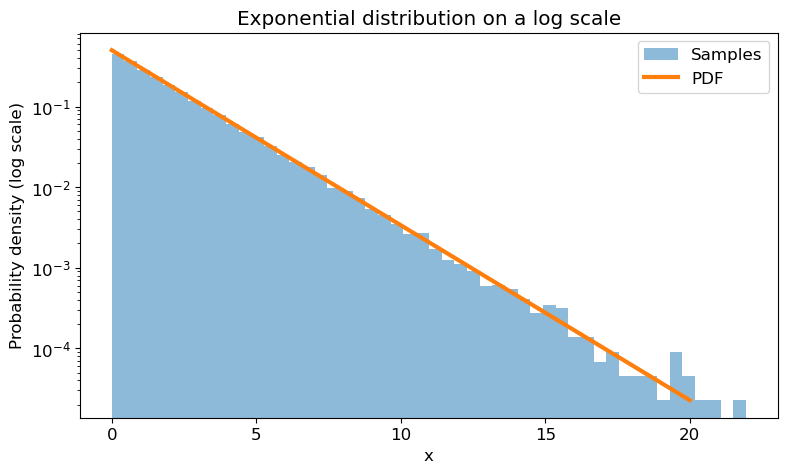

In [24]:
# on a log scale!
fig, ax = plt.subplots()
ax.hist(d, 50, density=True, alpha=0.5, label="Samples")
ax.plot(x, stats.expon.pdf(x, scale=scale), linewidth=3, label="PDF")
ax.set_yscale("log")
ax.set_xlabel("x")
ax.set_ylabel("Probability density (log scale)")
ax.set_title("Exponential distribution on a log scale")
ax.legend()
plt.show()

On the log scale, the theoretical curve is a straight line. Sample variations are noticeable in the tail because there are viewer samples.

### 3. Hypothetical Measurements

#### 3.A Select Value of a Hypothetical Measurement

In [25]:
measurement = 12.0

#### 3.B State Question

Assuming background only, what is the probability of a measurement at least as large as 12?

#### 3.C Convert to Math

$$p=P(X\geq12)=\int_{12}^{\infty}\frac12e^{-x/2}\,dx=e^{-6}.$$

#### 3.D Probability that Background Produced the Signal

`sf` gets us the upper tail, equal to `1 - cdf` for this continuous distribution.

In [26]:
p = stats.expon.sf(measurement, scale=scale)
print(f"Upper-tail probability: {p:.8f}")
print(f"Percentage: {100*p:.4f}%")

Upper-tail probability: 0.00247875
Percentage: 0.2479%


This is the prob of a result at least this large only if the background model is true.

#### 3.E Equivalent Sigma

We use the normal cutoff with the same upper-tail probability to get

$$z=\Phi^{-1}(1-p).$$

In [27]:
sigma = stats.norm.ppf(1 - p)
print(f"Equivalent significance: {sigma:.4f} sigma")

Equivalent significance: 2.8098 sigma


### 4. Explore

We try several hypothetical measurements and try to find any patterns!

In [28]:
measurements = np.array([1, 2, 4, 6, 8, 10, 12, 16, 20])
probabilities = stats.expon.sf(measurements, scale=scale)
sigmas = stats.norm.ppf(1 - probabilities)

print("measurement    probability    sigma")
for value, probability, sigma in zip(measurements, probabilities, sigmas):
    print(f"{value:11d}    {probability:.8f}    {sigma:.4f}")

measurement    probability    sigma
          1    0.60653066    -0.2703
          2    0.36787944    0.3375
          4    0.13533528    1.1015
          6    0.04978707    1.6469
          8    0.01831564    2.0898
         10    0.00673795    2.4709
         12    0.00247875    2.8098
         16    0.00033546    3.4012
         20    0.00004540    3.9139


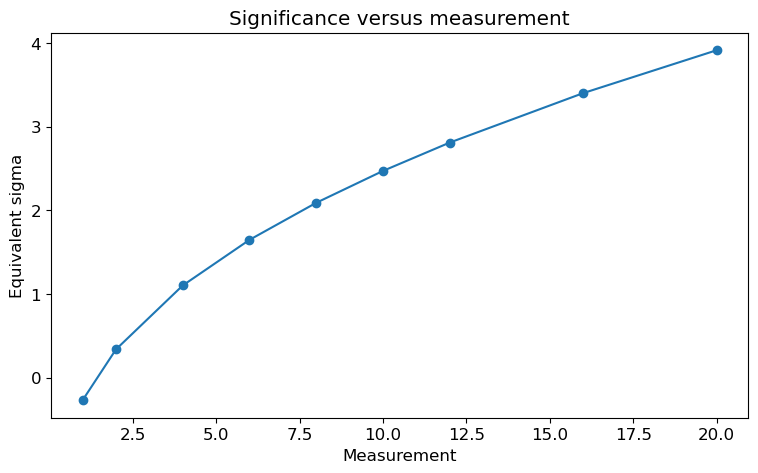

In [29]:
fig, ax = plt.subplots()
ax.plot(measurements, sigmas, "o-")
ax.set_xlabel("Measurement")
ax.set_ylabel("Equivalent sigma")
ax.set_title("Significance versus measurement")
plt.show()

Thus, as measruement increases its upper tail prob decreases and equivalent sigma increases. Sigma doesn't increase linearly. At a measruement of 1, we have the upper tail prob exceeding 0.5, so the equivalent sigma is negative.

### Optional: Poisson Distribution